# Customer Churn Prediction - Modeling

Train and evaluate models for churn prediction:
- Logistic Regression (baseline)
- Random Forest
- XGBoost

Metrics: accuracy, precision, recall, F1, ROC-AUC, confusion matrix.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}, churn rate: {y_train.mean():.4f}")

X_train: (5634, 29)
y_train: (5634,), churn rate: 0.2654


## 1. Baseline: Logistic Regression

Logistic Regression is a strong baseline for binary classification:
- Fast to train and interpret.
- Coefficients show feature importance directly.
- Works well when relationships are roughly linear (after scaling).

We use `class_weight='balanced'` to compensate for the 73/27 class imbalance - 
the model will penalize misclassifying the minority class (churners) more heavily.

In [6]:
# Train Logistic Regression
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train, y_train)

# Predictions
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]  # probabilities for class 1 (churn)

print("Training complete.")
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 probabilities: {y_proba[:5].round(3)}")

Training complete.
First 5 predictions: [0 1 0 1 0]
First 5 probabilities: [0.115 0.853 0.151 0.655 0.061]


## 2. Evaluation Metrics

For an imbalanced classification problem, we report multiple metrics:
- **Accuracy** - fraction of correct predictions overall.
- **Precision** - of predicted churners, how many actually churned?
- **Recall** - of actual churners, how many did we catch?
- **F1** - harmonic mean of precision and recall.
- **ROC-AUC** - overall ability to separate the two classes.

In churn, **recall matters most** - missing a churner means losing a customer.

In [8]:
# Compute all metrics
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1':        f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_proba)
}

print("Logistic Regression - Test Set Performance:")
print("=" * 45)
for metric, value in metrics.items():
    print(f"  {metric:10s}: {value:.4f}")

Logistic Regression - Test Set Performance:
  Accuracy  : 0.7374
  Precision : 0.5034
  Recall    : 0.7861
  F1        : 0.6138
  ROC-AUC   : 0.8420


## 3. Confusion Matrix

Visualizes the four prediction outcomes:
- **True Negatives (TN)** - correctly predicted "No churn"
- **True Positives (TP)** - correctly predicted "Churn"
- **False Negatives (FN)** - missed actual churners ⚠️ (costly!)
- **False Positives (FP)** - falsely flagged loyal customers (manageable)

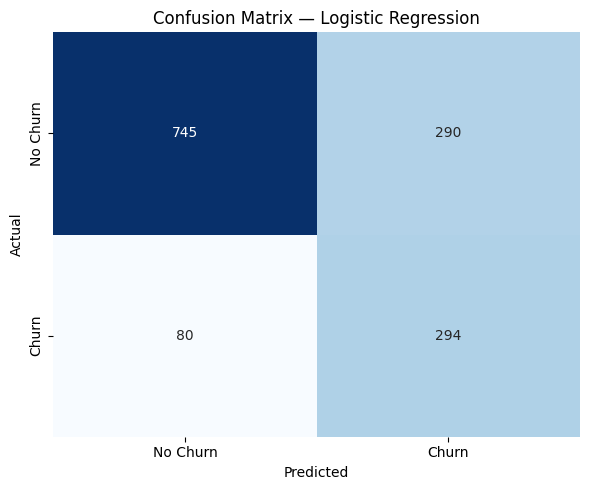


True Negatives:  745
False Positives: 290
False Negatives: 80
True Positives:  294


In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    cbar=False,
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

# Print breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

In [10]:
print("Classification Report — Logistic Regression")
print("=" * 50)
print(classification_report(
    y_test, y_pred, 
    target_names=['No Churn', 'Churn']
))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 4. Random Forest

Random Forest is an ensemble of decision trees trained on bootstrapped samples 
with random feature subsets. Advantages:
- Captures non-linear relationships and feature interactions.
- Handles mixed feature types well.
- Built-in feature importance.
- Robust to outliers and doesn't require scaling.

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest — Test Set Performance:")
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest — Test Set Performance:
  Accuracy : 0.7651
  Precision: 0.5429
  Recall   : 0.7273
  F1       : 0.6217
  ROC-AUC  : 0.8416


## 5. XGBoost

XGBoost (Extreme Gradient Boosting) is a state-of-the-art ensemble method 
that builds trees sequentially, where each tree corrects the errors of 
the previous ones. Widely used in industry and competitions for tabular data.

In [13]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imabalance in XGBoost
# Set it to the ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\nXGBoost — Test Set Performance:")
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_xgb):.4f}")

scale_pos_weight: 2.77

XGBoost — Test Set Performance:
  Accuracy : 0.7509
  Precision: 0.5229
  Recall   : 0.7032
  F1       : 0.5998
  ROC-AUC  : 0.8302


## 6. Model Comparison

Side-by-side comparison of all three models on the test set.

In [14]:
# Collect results from all models
results = pd.DataFrame({
    'Logistic Regression': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_proba_rf)
    ],
    'XGBoost': [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_proba_xgb)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])

results.round(4)

,Logistic Regression,Random Forest,XGBoost
Accuracy,0.7374,0.7651,0.7509
Precision,0.5034,0.5429,0.5229
Recall,0.7861,0.7273,0.7032
F1,0.6138,0.6217,0.5998
ROC-AUC,0.8420,0.8416,0.8302


## 7. Feature Importance

Random Forest provides built-in feature importance based on how much each 
feature reduces impurity across all trees. This tells us which factors 
drive churn the most.

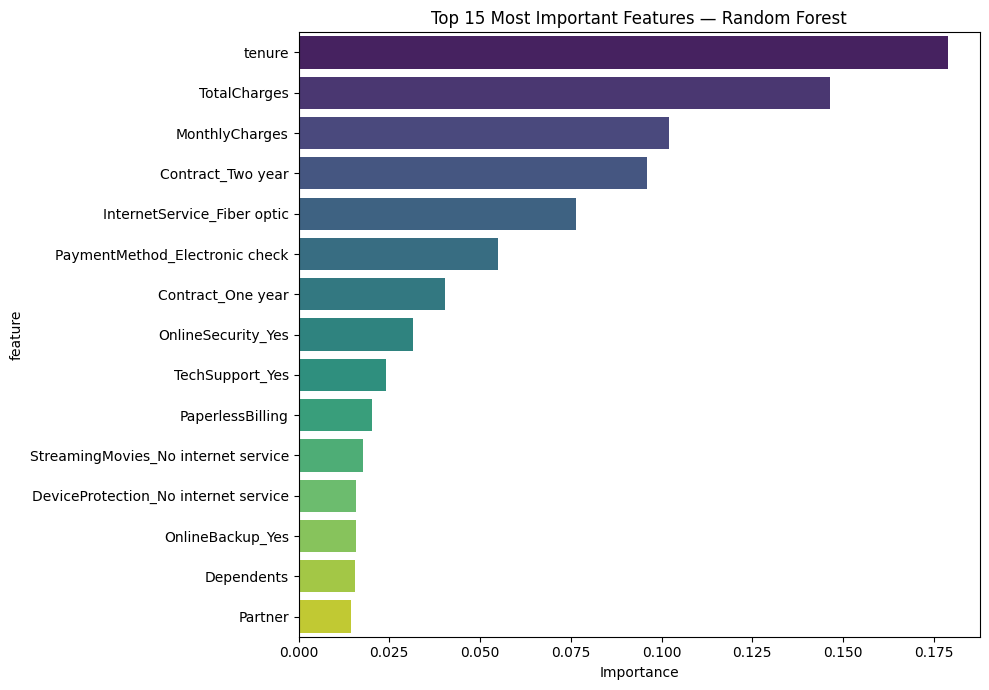

Top 10 features:
                       feature  importance
                        tenure    0.178790
                  TotalCharges    0.146368
                MonthlyCharges    0.102167
             Contract_Two year    0.095868
   InternetService_Fiber optic    0.076374
PaymentMethod_Electronic check    0.055022
             Contract_One year    0.040292
            OnlineSecurity_Yes    0.031633
               TechSupport_Yes    0.024202
              PaperlessBilling    0.020289


In [15]:
# Feature importance from Random Forest
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=importances.head(15), 
    x='importance', 
    y='feature', 
    hue='feature',
    palette='viridis',
    legend=False,
    ax=ax
)
ax.set_title('Top 15 Most Important Features — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).to_string(index=False))

### Key insights

The Random Forest's feature importance **confirms our EDA findings**:

- **Tenure** is the #1 predictor - new customers (low tenure) are the highest risk group.
- **Contract type** matters strongly - two-year contracts dramatically reduce churn.
- **Fiber optic internet** users churn at high rates, despite being premium customers - 
  suggests service quality or pricing concerns.
- **Electronic check** as a payment method correlates with churn - these customers 
  are less "locked in" than auto-payment users.
- **Add-on services** (OnlineSecurity, TechSupport) reduce churn - each service 
  increases customer stickiness.

**Business recommendations:**
1. Focus retention efforts on customers in the first 6 months.
2. Incentivize migration to longer contracts.
3. Investigate fiber optic service quality issues.
4. Encourage auto-payment methods.
5. Cross-sell add-on services to month-to-month customers.

## 8. ROC Curves

ROC curve plots **True Positive Rate (recall)** vs **False Positive Rate** 
at different classification thresholds. A curve closer to the top-left corner 
means better separation between classes. AUC summarizes this in a single number.

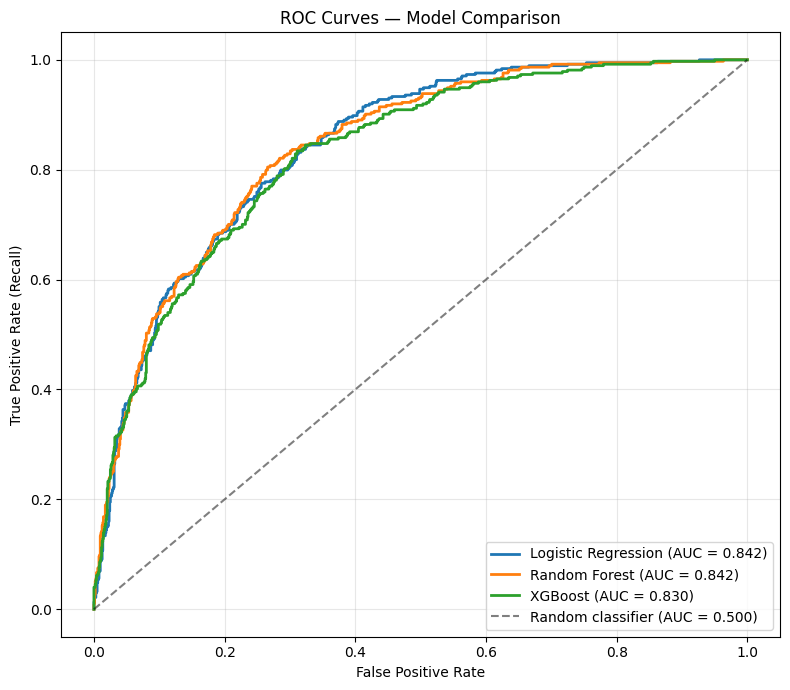

In [16]:
from sklearn.metrics import roc_curve

# Compute ROC curves for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.3f})', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})', linewidth=2)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.500)', alpha=0.5)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()